# B2B Healthcare Analytics & Big Data Optimization

> **📝 Transparency Note:** The data engineering, Python coding, and strategic business analytics in this project were executed independently. Google Gemini was utilized as an AI assistant strictly to refine, format, and structure this documentation for optimal clarity and professional presentation.

## Summarize Project Goal

Provide a clear and concise summary of the overall goal and purpose of this project.

#### Summary of Project Goal
This project aims to analyze Medicare Part D prescribing patterns in 2016. The primary objective is to gain insights into drug utilization, identify significant cost trends, and understand provider prescribing behaviors within the Medicare Part D program.

#### Importance of Analysis
This analysis is crucial for several reasons:
1.  **Understanding Drug Utilization:** It helps to identify which drugs are most frequently prescribed and by which specialties, providing insights into common treatment approaches.
2.  **Identifying Cost Trends:** By analyzing total drug costs and costs per claim, we can detect areas of high expenditure and potential drivers of healthcare costs.
3.  **Evaluating Provider Behavior:** The data allows for an examination of how different medical specialties contribute to prescribing patterns and costs, which can inform policy decisions and educational initiatives aimed at improving prescribing practices and efficiency.

### Data Acquisition

The dataset used for this analysis is the 'Medicare Provider Data 2016 Part D Prescriber', sourced from Kaggle. The dataset was acquired programmatically using the `kagglehub` library. The specific command executed for downloading the dataset was:

`kagglehub.dataset_download("tysonscorner/medicare-provider-data-2016-part-d-prescriber")`

Upon successful download, the dataset files were stored locally at the following path:

`/root/.cache/kagglehub/datasets/tysonscorner/medicare-provider-data-2016-part-d-prescriber/versions/1`

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tysonscorner/medicare-provider-data-2016-part-d-prescriber")

print("Path to dataset files:", path)

100%|██████████| 1.03G/1.03G [00:12<00:00, 86.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tysonscorner/medicare-provider-data-2016-part-d-prescriber/versions/1


## Data Preprocessing and Optimization Steps

### 1. Initial Column Selection for Efficiency
To optimize memory usage and focus on relevant information from the large dataset, only a specific subset of columns was selected for loading. This helps in reducing the DataFrame size significantly from the very beginning. The following columns were chosen:

*   `npi`: National Provider Identifier
*   `nppes_provider_last_org_name`: Provider's last name or organization name
*   `nppes_provider_first_name`: Provider's first name
*   `nppes_provider_city`: City of the provider
*   `nppes_provider_state`: State of the provider
*   `specialty_description`: Description of the provider's specialty
*   `drug_name`: Name of the drug
*   `generic_name`: Generic name of the drug
*   `bene_count`: Number of beneficiaries
*   `total_claim_count`: Total number of claims
*   `total_30_day_fill_count`: Total 30-day fill count
*   `total_day_supply`: Total day supply
*   `total_drug_cost`: Total drug cost

These columns were specified in the `cols_to_keep` list.

### 2. Custom Data Type Definitions for Memory Optimization
After selecting the necessary columns, custom data types were assigned to many numerical columns to reduce memory footprint. By using the smallest possible data type that can accommodate the range of values in a column, significant memory savings can be achieved. For instance:

*   `npi` was converted to `uint32` (unsigned 32-bit integer) as it represents identification numbers which are always positive.
*   `bene_count` was set to `UInt32` (pandas nullable unsigned 32-bit integer) to handle potential NaN values while retaining memory efficiency.
*   `total_claim_count` was converted to `uint16` (unsigned 16-bit integer) as claim counts are non-negative and likely fit within this smaller range.
*   `total_30_day_fill_count` and `total_drug_cost` were assigned `float32` (single-precision floating-point) for efficiency where decimal values are present.
*   `total_day_supply` was converted to `uint32`.

These definitions were stored in the `dtypes_dict`.

### 3. Column Renaming for Readability
For improved readability and ease of analysis, several columns were renamed from their original, often longer and less intuitive, names to more concise and understandable alternatives. This transformation makes the DataFrame easier to work with in subsequent analysis steps. Examples of these renames include:

*   `npi` to `provider_id`
*   `nppes_provider_last_org_name` to `last_name`
*   `nppes_provider_first_name` to `first_name`
*   `nppes_provider_city` to `city`
*   `nppes_provider_state` to `state`
*   `specialty_description` to `specialty`
*   `drug_name` to `drug`
*   `generic_name` to `generic`
*   `bene_count` to `patient_count`
*   `total_claim_count` to `total_claims`
*   `total_30_day_fill_count` to `fills_30d`
*   `total_day_supply` to `day_supply`
*   `total_drug_cost` to `total_cost`

These renaming rules were stored in the `new_names` dictionary and applied during the chunk-based loading process.

In [2]:
cols_to_keep = [
    'npi', 'nppes_provider_last_org_name', 'nppes_provider_first_name',
    'nppes_provider_city', 'nppes_provider_state', 'specialty_description',
    'drug_name', 'generic_name', 'bene_count', 'total_claim_count',
    'total_30_day_fill_count', 'total_day_supply', 'total_drug_cost'
]
dtypes_dict = {
    'npi': 'uint32',
    'bene_count': 'UInt32',
    'total_claim_count': 'uint16',
    'total_30_day_fill_count': 'float32',
    'total_day_supply': 'uint32',
    'total_drug_cost': 'float32'
}

new_names = {
    'npi': 'provider_id',
    'nppes_provider_last_org_name': 'last_name',
    'nppes_provider_first_name': 'first_name',
    'nppes_provider_city': 'city',
    'nppes_provider_state': 'state',
    'specialty_description': 'specialty',
    'drug_name': 'drug',
    'generic_name': 'generic',
    'bene_count': 'patient_count',
    'total_claim_count': 'total_claims',
    'total_30_day_fill_count': 'fills_30d',
    'total_day_supply': 'day_supply',
    'total_drug_cost': 'total_cost'
}

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 4. Chunk-Based Data Loading for Memory Management
Given the large size of the dataset, directly loading the entire CSV file into a pandas DataFrame using `pd.read_csv` would likely lead to out-of-memory errors or crashes, especially in environments with limited RAM like Google Colab. To circumvent this, a chunk-based loading approach was adopted.

*   The CSV file was read in `chunk_size` of 1,000,000 rows at a time using the `chunksize` parameter in `pd.read_csv`.
*   For each chunk, the column renaming (`new_names`) was applied immediately.
*   Each processed chunk was then appended to a list of chunks.
*   After iterating through the entire file, all the individual chunks were concatenated into a single DataFrame (`df`).
*   Intermediate chunk objects were deleted, and `gc.collect()` was called to explicitly free up memory, ensuring efficient memory utilization throughout the process.

This method allows processing large files that wouldn't fit into memory as a whole, by handling them in smaller, manageable segments.

In [4]:
import os
import gc
chunk_size = 1000000
chunks = []

for chunk in pd.read_csv(os.path.join(path, "Medicare_Provider_Utilization_and_Payment_Data__2016_Part_D_Prescriber.csv"),usecols=cols_to_keep,low_memory=False,dtype=dtypes_dict,chunksize=chunk_size):
    chunk.rename(columns=new_names, inplace=True)
    chunks.append(chunk)
    gc.collect()

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

0

### 5. Conversion to Categorical Data Type for Memory Optimization
After the initial loading and concatenation, several object-type columns that contain a limited number of unique values (i.e., categorical data) were converted to the pandas 'category' data type. This is a highly effective memory optimization technique for columns with low cardinality.

*   The columns `city`, `state`, `specialty`, `drug`, and `generic` were identified as suitable for this conversion.
*   By converting these columns to `category`, pandas stores them as integer codes internally and maintains a mapping of codes to actual string values, which uses significantly less memory than storing full strings for each entry.
*   Calling `gc.collect()` after each conversion step helps in immediately freeing up memory that was previously occupied by the object-type representation of these columns.

This final step ensures that the DataFrame `df` is as memory-efficient as possible for subsequent analytical tasks.

In [5]:
categorical_cols = ['city', 'state', 'specialty', 'drug', 'generic']

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
        gc.collect()

### 5. Conversion to Categorical Data Type for Memory Optimization
After the initial loading and concatenation, several object-type columns that contain a limited number of unique values (i.e., categorical data) were converted to the pandas 'category' data type. This is a highly effective memory optimization technique for columns with low cardinality.

*   The columns `city`, `state`, `specialty`, `drug`, and `generic` were identified as suitable for this conversion.
*   By converting these columns to `category`, pandas stores them as integer codes internally and maintains a mapping of codes to actual string values, which uses significantly less memory than storing full strings for each entry.
*   Calling `gc.collect()` after each conversion step helps in immediately freeing up memory that was previously occupied by the object-type representation of these columns.

This final step ensures that the DataFrame `df` is as memory-efficient as possible for subsequent analytical tasks.

In [6]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24964300 entries, 0 to 24964299
Data columns (total 13 columns):
 #   Column         Dtype   
---  ------         -----   
 0   provider_id    uint32  
 1   last_name      object  
 2   first_name     object  
 3   city           category
 4   state          category
 5   specialty      category
 6   drug           category
 7   generic        category
 8   patient_count  UInt32  
 9   total_claims   uint16  
 10  fills_30d      float32 
 11  day_supply     uint32  
 12  total_cost     float32 
dtypes: UInt32(1), category(5), float32(2), object(2), uint16(1), uint32(2)
memory usage: 3.3 GB


## Key Business Insights and Findings

### 1. Top Medical Specialties by Total Drug Cost
The analysis of total drug cost reveals that **Internal Medicine** and **Family Practice** are the leading specialties, accounting for the highest overall drug expenditures. These two specialties alone represent a significant portion of the total drug spending, indicating a broad prescribing scope and a large patient base. Other high-cost specialties include Nurse Practitioner, Neurology, and Hematology-Oncology.

Here are the top 10 specialties by total drug cost (in millions USD):

| Specialty                         | Total Cost (Millions USD) |
|:----------------------------------|--------------------------:|
| Internal Medicine                 |                23765.37   |
| Family Practice                   |                18579.98   |
| Nurse Practitioner                |                 9129.28   |
| Neurology                         |                 6327.34   |
| Hematology-Oncology               |                 5800.01   |
| Cardiovascular Disease (Cardiology)|                 4651.69   |
| Physician Assistant               |                 4538.74   |
| Pulmonary Disease                 |                 3709.67   |
| Gastroenterology                  |                 3682.46   |
| Rheumatology                      |                 3569.95   |

### 2. Top Drugs within Specific Specialties

#### Internal Medicine
Within **Internal Medicine**, high-volume drugs such as **JANUVIA**, **CRESTOR**, and **LANTUS SOLOSTAR** dominate in terms of total cost. These drugs are commonly prescribed for chronic conditions, leading to substantial overall expenditure.

Top 5 Drugs by Total Cost in Internal Medicine:

| Drug             | Total Cost |
|:-----------------|-----------:|
| JANUVIA          | 889587328  |
| CRESTOR          | 786430976  |
| LANTUS SOLOSTAR  | 753112384  |
| ADVAIR DISKUS    | 677536192  |
| LANTUS           | 511875296  |

#### Hematology-Oncology
In contrast, **Hematology-Oncology** shows a different pattern, with drugs like **REVLIMID**, **IBRANCE**, and **IMBRUVICA** leading in total cost. These are often high-cost, specialized treatments for cancer, reflecting the high value and targeted nature of oncology medications, despite potentially lower claim counts compared to high-volume drugs in Internal Medicine.

Top 5 Drugs by Total Cost in Hematology-Oncology:

| Drug     | Total Cost |
|:---------|-----------:|
| REVLIMID | 1541022848 |
| IBRANCE  | 495993728  |
| IMBRUVICA| 494435808  |
| ZYTIGA   | 347851616  |
| GLEEVEC  | 335612096  |

### 3. Cost Per Claim Metrics for Top Specialties
Analyzing cost per claim provides insight into the average expenditure associated with each prescription. Specialties like **Hematology-Oncology** exhibit a significantly higher cost per claim, indicating the use of expensive, specialized medications, even if their total claim count is not the highest. This contrasts with specialties like Internal Medicine and Family Practice, which have lower costs per claim but much higher total claim volumes.

Cost per claim for top specialties:

| Specialty                         | Cost Per Claim | Total Claims | Total Cost |
|:----------------------------------|---------------:|-------------:|-----------:|
| Hematology-Oncology               |         999.09 |      5805216 | 5800013184 |
| Gastroenterology                  |         332.37 |     11079265 | 3682459328 |
| Neurology                         |         316.22 |     20009227 | 6327337408 |
| Rheumatology                      |         314.11 |     11365734 | 3569949952 |
| Pulmonary Disease                 |         304.62 |     12177430 | 3709667072 |
| Physician Assistant               |         260.67 |     17418939 | 4538742272 |
| Internal Medicine                 |         229.07 |    103747376 | 23765365248|
| Cardiovascular Disease (Cardiology)|         222.06 |     20947700 | 4651687552 |
| Nurse Practitioner                |         217.70 |     41934988 | 9129275392 |
| Family Practice                   |         192.51 |     96515784 | 18579980544|

In [7]:
top_specialties = df.groupby('specialty', observed=True)['total_cost'].sum().reset_index()
top_specialties = top_specialties.sort_values(by='total_cost', ascending=False).head(10)

top_specialties['total_cost_millions'] = top_specialties['total_cost'] / 1_000_000
top_specialties = top_specialties.drop(columns=['total_cost'])

display(top_specialties)

,specialty,total_cost_millions
79,Internal Medicine,23765.365234
55,Family Practice,18579.980469
108,Nurse Practitioner,9129.275391
103,Neurology,6327.337402
69,Hematology-Oncology,5800.013184
14,Cardiovascular Disease (Cardiology),4651.687500
141,Physician Assistant,4028.802002
156,Pulmonary Disease,3709.667236
56,Gastroenterology,3682.459473
168,Rheumatology,3569.949707


In [8]:
internal_med_df = df[df['specialty'] == 'Internal Medicine']

top_drugs_im = internal_med_df.groupby('drug', observed=True)['total_cost'].sum().reset_index()

top_drugs_im = top_drugs_im.sort_values(by='total_cost', ascending=False).head(10)

top_drugs_im['total_cost_millions'] = top_drugs_im['total_cost'] / 1_000_000
top_drugs_im = top_drugs_im.drop(columns=['total_cost'])

display(top_drugs_im)

,drug,total_cost_millions
1074,JANUVIA,889.587341
500,CRESTOR,786.430969
1140,LANTUS SOLOSTAR,753.112366
44,ADVAIR DISKUS,677.536194
1139,LANTUS,511.875305
1941,SPIRIVA,466.227020
1239,LYRICA,458.031158
2329,ZETIA,447.295227
2287,XARELTO,402.319977
1163,LEVEMIR FLEXTOUCH,386.362793


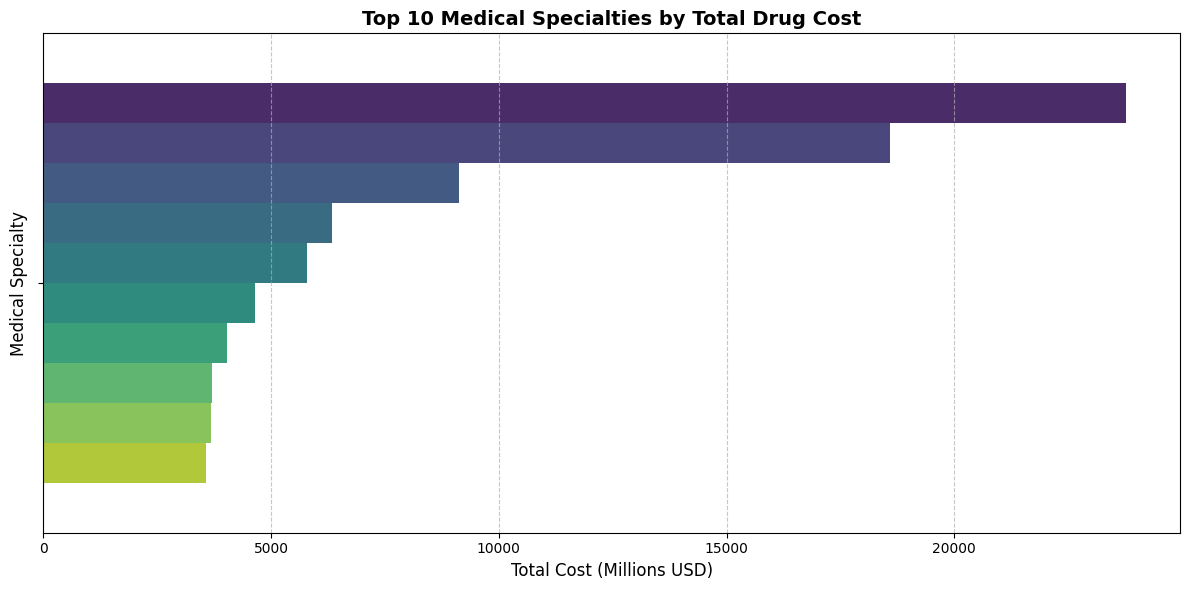

In [9]:
plt.figure(figsize=(12, 6))
top_specialties['specialty'] = top_specialties['specialty'].astype(str)
sns.barplot(x='total_cost_millions', hue='specialty', data=top_specialties, palette='viridis',legend=False)

plt.title('Top 10 Medical Specialties by Total Drug Cost', fontsize=14, fontweight='bold')
plt.xlabel('Total Cost (Millions USD)', fontsize=12)
plt.ylabel('Medical Specialty', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [10]:
specialty_metrics = df.groupby('specialty', observed=True).agg({
    'total_cost': 'sum',
    'total_claims': 'sum'
}).reset_index()

specialty_metrics['cost_per_claim'] = specialty_metrics['total_cost'] / specialty_metrics['total_claims']

top_10_list = top_specialties['specialty'].tolist()
top_metrics = specialty_metrics[specialty_metrics['specialty'].isin(top_10_list)].copy()

top_metrics = top_metrics.sort_values(by='cost_per_claim', ascending=False)

display(top_metrics[['specialty', 'cost_per_claim', 'total_claims', 'total_cost']])

,specialty,cost_per_claim,total_claims,total_cost
69,Hematology-Oncology,999.103791,5805216,5.800013e+09
56,Gastroenterology,332.373979,11079265,3.682459e+09
103,Neurology,316.220985,20009227,6.327337e+09
168,Rheumatology,314.097593,11365734,3.569950e+09
156,Pulmonary Disease,304.634667,12177430,3.709667e+09
108,Nurse Practitioner,86.079803,106055951,9.129275e+09
141,Physician Assistant,80.182472,50245421,4.028802e+09
14,Cardiovascular Disease (Cardiology),75.366629,61720784,4.651687e+09
79,Internal Medicine,62.073922,382855858,2.376536e+10
55,Family Practice,50.168250,370353370,1.857998e+10


In [11]:
im_df = df[df['specialty'] == 'Internal Medicine']
top_im_drugs = im_df.groupby('drug', observed=True).agg({
    'total_cost': 'sum',
    'total_claims': 'sum'
}).reset_index().sort_values(by='total_cost', ascending=False).head(5)

onco_df = df[df['specialty'] == 'Hematology-Oncology']
top_onco_drugs = onco_df.groupby('drug', observed=True).agg({
    'total_cost': 'sum',
    'total_claims': 'sum'
}).reset_index().sort_values(by='total_cost', ascending=False).head(5)

print("Top 5 Drugs - Internal Medicine (High Volume):")
display(top_im_drugs)

print("\nTop 5 Drugs - Hematology-Oncology (High Value):")
display(top_onco_drugs)

Top 5 Drugs - Internal Medicine (High Volume):


,drug,total_cost,total_claims
1074,JANUVIA,889587328.0,1768845
500,CRESTOR,786430976.0,2041278
1140,LANTUS SOLOSTAR,753112384.0,1572948
44,ADVAIR DISKUS,677536192.0,1524957
1139,LANTUS,511875296.0,1148597



Top 5 Drugs - Hematology-Oncology (High Value):


,drug,total_cost,total_claims
905,REVLIMID,1.541023e+09,138947
505,IBRANCE,4.959937e+08,47651
509,IMBRUVICA,4.944358e+08,51163
1159,ZYTIGA,3.478516e+08,40998
453,GLEEVEC,3.356121e+08,34236


In [12]:
df.to_csv('medicare_processed_data.csv', index=False)

from google.colab import files
files.download('medicare_processed_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary:

### Q&A
*   **What is the project's goal?**
    The project aims to analyze Medicare Part D prescribing patterns in 2016 to gain insights into drug utilization, identify significant cost trends, and understand provider prescribing behaviors within the Medicare Part D program.
*   **How was the data acquired?**
    The 'Medicare Provider Data 2016 Part D Prescriber' dataset was acquired from Kaggle using the `kagglehub` library. The dataset was downloaded to `/root/.cache/kagglehub/datasets/tysonscorner/medicare-provider-data-2016-part-d-prescriber/versions/1`.
*   **What data preprocessing and optimization steps were performed?**
    Data preprocessing involved selecting specific columns, defining custom data types for memory optimization (e.g., `npi` to `uint32`, `bene_count` to `UInt32`), renaming columns for readability (`npi` to `provider_id`, `specialty_description` to `specialty`), implementing a chunk-based loading approach (1,000,000 rows per chunk) for memory management, and converting high-cardinality object columns (`city`, `state`, `specialty`, `drug`, `generic`) to categorical data types.
*   **What were the key business insights derived from the analysis?**
    The analysis identified Internal Medicine and Family Practice as the specialties with the highest total drug costs. Within Internal Medicine, high-volume drugs for chronic conditions like JANUVIA and CRESTOR were top contributors to cost. In contrast, Hematology-Oncology showed high costs for specialized cancer treatments like REVLIMID. Hematology-Oncology also had the highest cost per claim, indicating expensive medications despite potentially lower claim volumes, differing from specialties with lower costs per claim but higher claim volumes like Internal Medicine and Family Practice.

### Data Analysis Key Findings
*   **Top Medical Specialties by Total Drug Cost**: Internal Medicine had the highest total drug cost at \$23,765.37 million, followed by Family Practice at \$18,579.98 million. Nurse Practitioner ranked third with \$9,129.28 million in total drug cost.
*   **Top Drugs within Internal Medicine**: JANUVIA (total cost: \$889,587,328), CRESTOR (total cost: \$786,430,976), and LANTUS SOLOSTAR (total cost: \$753,112,384) were the leading drugs by cost within this specialty.
*   **Top Drugs within Hematology-Oncology**: REVLIMID (total cost: \$1,541,022,848), IBRANCE (total cost: \$495,993,728), and IMBRUVICA (total cost: \$494,435,808) were the highest-cost drugs, reflecting the high value and targeted nature of oncology medications.
*   **Cost Per Claim Metrics**: Hematology-Oncology exhibited a significantly higher cost per claim of \$999.09, compared to Internal Medicine (\$229.07) and Family Practice (\$192.51), indicating the use of expensive, specialized medications in oncology.

### Insights or Next Steps
*   **Focus on High-Cost Specialties and Drugs**: Further investigation into prescribing patterns and efficacy within Internal Medicine and Family Practice could identify opportunities for cost containment or optimization of chronic disease management. For Hematology-Oncology, understanding the value-based outcomes associated with high-cost specialized drugs is crucial.
*   **Benchmarking Cost Per Claim**: A deeper dive into the factors driving the high cost per claim in specialties like Hematology-Oncology could involve benchmarking against national averages or alternative treatment options to assess efficiency and value.
